In [2]:
import matplotlib.pyplot as plt
from collections import Counter
from data.load_data import extract_mtriples, extract_mtriples_by_category

In [3]:
xml_path = "data/long-inputs_GREC_3_10.xml"
result = extract_mtriples(xml_path)
sorted_data = extract_mtriples_by_category(xml_path)
sorted_data.keys()

dict_keys(['Cities', 'People'])

In [4]:
# result is the output of extract_mtriples()
length = [len(entry) for entry in result]

# Convert to a dict: {entry_index: triple_count}
entry_lengths = {f"Entry_{i}": count for i, count in enumerate(length)}

# print(f"Entry triple counts:\n {entry_lengths}")

# Get the values, sort them
lengths = sorted(entry_lengths.values())

# Find keys (entry indices) for min and max triple counts
max_key = max(entry_lengths, key=entry_lengths.get)
min_key = min(entry_lengths, key=entry_lengths.get)

# Print summary stats
print("Summary:")
print(f"Total entries: {len(lengths)}")
print(f"Minimum triples: {lengths[0]}")
print(f"Maximum triples: {lengths[-1]}")
print(f"Average triples: {sum(lengths) / len(lengths):.2f}")
print(f"Entry with maximum triples: Entry {max_key} → {entry_lengths[max_key]} triples")
print(f"Entry with minimum triples: Entry {min_key} → {entry_lengths[min_key]} triples")


Summary:
Total entries: 533
Minimum triples: 10
Maximum triples: 86
Average triples: 26.30
Entry with maximum triples: Entry Entry_105 → 86 triples
Entry with minimum triples: Entry Entry_199 → 10 triples


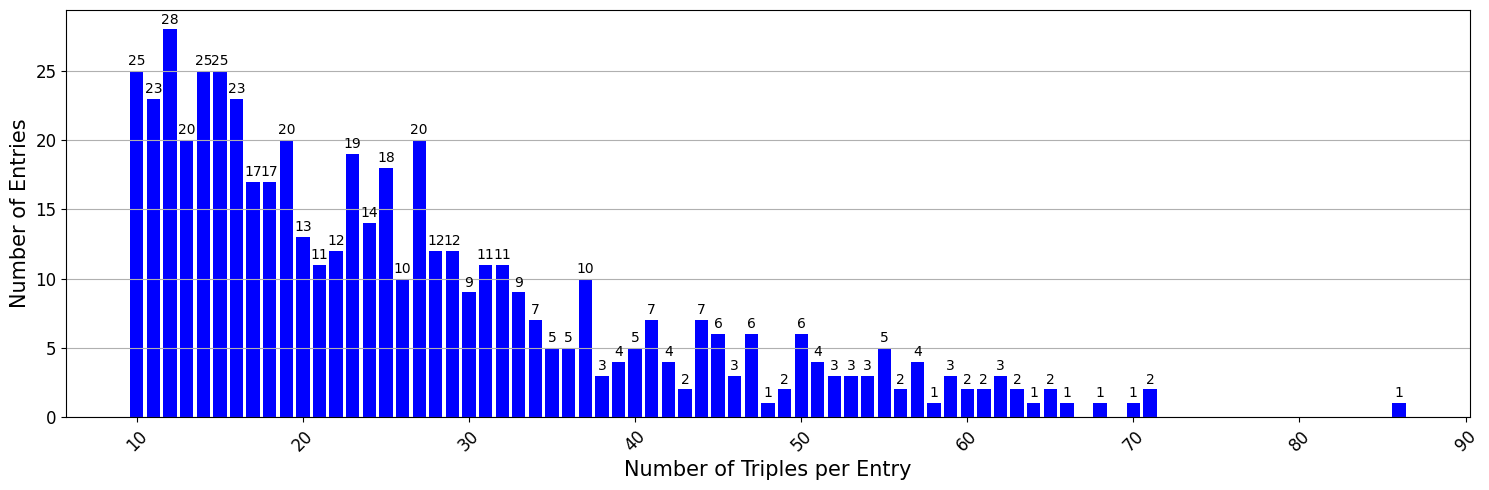

In [22]:
# Calculate the distribution
length_counts = Counter(lengths)
sorted_lengths = sorted(length_counts.items())
x_vals, y_vals = zip(*sorted_lengths)

# Enhanced Plotting Code75
plt.figure(figsize=(15, 5))
bars = plt.bar(x_vals, y_vals, color='blue')

# Annotate each bar with the count value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.2, str(height),
             ha='center', va='bottom', fontsize=10)

# Axis labeling and aesthetics
plt.xlabel('Number of Triples per Entry', fontsize=15)
plt.ylabel('Number of Entries', fontsize=15)
# plt.title('Distribution of Triple Counts per Entry (with Counts)', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.tight_layout()

# Save plot locally (uncomment the line below to save)
plt.savefig("data/triple_distribution.png", dpi=300)
plt.show()

In [5]:
g60 = [n for n, i in enumerate(length)  if i > 60]
g60

[2, 10, 26, 35, 37, 50, 82, 85, 92, 95, 99, 105, 137, 158, 159, 213]

In [6]:
n = 85
len(result[n])

66

In [7]:
from utilities.llm_model import UnifiedModel, model_name
from utilities.prompt import MODEL_PROMPT, MODEL_PROMPT2, INPUT_PROMPT

provider = "anthropic"
conf = model_name.get(provider.lower())
llm = UnifiedModel(provider=provider, **conf).model_(MODEL_PROMPT)
output = llm.invoke({'input': INPUT_PROMPT.format(triples=result[n])}).content.strip()
if "</think>" in output:
    output = output.split("<think>")[1].strip()
print(f"\nGenerated Text:\n{output}")


SyntaxError: invalid syntax. Perhaps you forgot a comma? (llm_model.py, line 19)

In [6]:
output = "Islamabad, the federal capital of Pakistan, is a significant metropolitan area with a rich history and diverse institutional presence. Founded on August 14, 1967, the city serves as the capital for Pakistan, and historically was also the capital of West Pakistan. The city is governed by the Islamabad Metropolitan Corporation and its residents are known as Islamabadis.\n\nThe city's geography and demographics present an interesting profile. Islamabad covers a total area of 220 square kilometers, with an urban area of 220.15 square kilometers and a larger metropolitan region spanning 1,165.5 square kilometers. The city has a total population of 1,009,832, while its metropolitan area houses 2,003,368 residents. The population density stands at 2,089 people per square kilometer. For administrative purposes, the city uses the area code 051 and postal code 44000, operating in the Pakistan Standard Time zone with a UTC offset of +05:00.\n\nIslamabad hosts numerous important governmental and educational institutions. The Cabinet Secretariat, Capital Development Authority, and Public-Private Partnership Authority maintain their headquarters here. Several prestigious educational institutions have established their presence in the city, including Quaid-i-Azam University, the University of Lahore, Pakistan Institute of Public Finance Accountants, Al-Hamd Islamic University, and Capital University of Science & Technology. Preston University and Pak-Turk Maarif International Schools & Colleges also operate in the region.\n\nThe city has been home to various notable personalities and events. Notable individuals born in Islamabad include Rohail Nazir, Sarmad Tariq, and Humaira Bano, while prominent figures such as Qazi Hussain Ahmad, Rufin Anthony, and Samina Raja passed away in the city. Islamabad is also home to several musicians and artists, with Qayaas, Adil Omar, and Faakhir Mehmood claiming it as their hometown. Distinguished residents include Qaiser Mushtaq, Qamar Zaman Chaudhry, and Roedad Khan.\n\nThe city serves as a crucial administrative and military center, hosting various organizations including the President's Bodyguard, the Pakistan Air Force, and the Corona Relief Tiger Force. Commercial entities such as the Utility Stores Corporation, Hashoo Group, and Islamabad Electric Supply Company are based here. The city is served by various civic organizations including the Islamabad Chamber of Commerce & Industry, Islamabad Football Association, and the Islamabad Metropolitan Corporation. The Margalla Hills National Park is located near the city, and notable developments like Model Town Humak fall under Islamabad's administration. The city's planning and development were significantly influenced by Constantinos Apostolou Doxiadis, who included Islamabad among his significant projects."
print(output)

Islamabad, the federal capital of Pakistan, is a significant metropolitan area with a rich history and diverse institutional presence. Founded on August 14, 1967, the city serves as the capital for Pakistan, and historically was also the capital of West Pakistan. The city is governed by the Islamabad Metropolitan Corporation and its residents are known as Islamabadis.

The city's geography and demographics present an interesting profile. Islamabad covers a total area of 220 square kilometers, with an urban area of 220.15 square kilometers and a larger metropolitan region spanning 1,165.5 square kilometers. The city has a total population of 1,009,832, while its metropolitan area houses 2,003,368 residents. The population density stands at 2,089 people per square kilometer. For administrative purposes, the city uses the area code 051 and postal code 44000, operating in the Pakistan Standard Time zone with a UTC offset of +05:00.

Islamabad hosts numerous important governmental and educa

In [5]:
retranslate = """Islamabad, the federal capital of Pakistan, is a major metropolitan area with a rich history and diverse institutional presence. Established on 14 August 1967, the city serves as the capital of Pakistan, and was also historically the capital of West Pakistan. The city is governed by the Islamabad Metro Corporation and its residents are known as Islamabadis.

The geography and demographics of the city present an interesting profile. Islamabad covers a total area of ​​220 square kilometres, with an urban area of ​​220.15 square kilometres and a larger metro area extending over 1,165.5 square kilometres. The city has a total population of 1,009,832, while its metro area has 2,003,368 residents. The population density stands at 2,089 persons per square kilometre. For administrative purposes, the city uses the area code 051 and postal code 44000, operating in the Pakistan Standard Time zone with a UTC offset of +05:00.

Islamabad hosts important government and educational institutions. The Cabinet Secretariat, the Capital Development Authority, and the Public-Private Partnership Authority maintain their headquarters here. Several prominent educational institutions are based in the city, including Quaid-i-Azam University, the University of Lahore, the Pakistan Institute of Public Financial Accountants, Al-Hamd Islamic University, and the Capital University of Science & Technology. Preston University and Pak-Turk Maarif International Schools & Colleges also operate in the region.

The city has been home to several notable personalities and events. Notable people born in Islamabad include Rohail Nazir, Sarmad Tariq, and Humaira Bano, while prominent figures such as Qazi Hussain Ahmad, Rufin Anthony, and Samina Raja passed away in the city. Islamabad is also home to several musicians and artists, with Qayaas, Adil Omar, and Faakhir Mehmood claiming it as their hometown. Notable residents include Qaiser Mushtaq, Qamar Zaman Chaudhry, and Roedad ​​Khan.

The city serves as a vital administrative and military center, hosting various organizations including the Presidential Guard, Pakistan Air Force, and the Corona Relief Tiger Force. Commercial entities such as the Convenience Stores Corporation, Hashoo Group, and Islamabad Electric Supply Company are located here. The city is served by various civic organizations including the Islamabad Chamber of Commerce & Industry, Islamabad Football Association, and Islamabad Metro Corporation. The Margalla Hills National Park is located close to the city, and notable developments such as the Humak Model Town come under the administration of Islamabad. Constantinos Apostolou Doxiadis had a significant influence on the planning and development of the city, who included Islamabad among his notable projects.
"""

print(retranslate)

Islamabad, the federal capital of Pakistan, is a major metropolitan area with a rich history and diverse institutional presence. Established on 14 August 1967, the city serves as the capital of Pakistan, and was also historically the capital of West Pakistan. The city is governed by the Islamabad Metro Corporation and its residents are known as Islamabadis.

The geography and demographics of the city present an interesting profile. Islamabad covers a total area of ​​220 square kilometres, with an urban area of ​​220.15 square kilometres and a larger metro area extending over 1,165.5 square kilometres. The city has a total population of 1,009,832, while its metro area has 2,003,368 residents. The population density stands at 2,089 persons per square kilometre. For administrative purposes, the city uses the area code 051 and postal code 44000, operating in the Pakistan Standard Time zone with a UTC offset of +05:00.

Islamabad hosts important government and educational institutions. The 

In [3]:
from utilities.llm_model import AnthropicModel

model = AnthropicModel(model_name="claude-3-5-sonnet-latest").raw_model()
translate = model.invoke(f"""Translate the following text to Irish. It should be fluent and have no hallucinations. 
Do not add introductory phrases or explanations.
Text:\n{output}""").content.strip()
print(translate)

Islamabad, príomhchathair chónaidhme na Pacastáine, is mórcheantar suntasach é le stair shaibhir agus láithreacht institiúideach éagsúil. Bunaíodh é ar 14 Lúnasa 1967, feidhmíonn an chathair mar phríomhchathair na Pacastáine, agus go stairiúil bhí sé mar phríomhchathair Iarthar na Pacastáine freisin. Rialaíonn Corparáid Mheitrealach Islamabad an chathair agus tugtar Islamabadis ar a cónaitheoirí.

Léiríonn tíreolaíocht agus déimeagrafaic na cathrach próifíl suimiúil. Clúdaíonn Islamabad achar iomlán de 220 ciliméadar cearnach, le ceantar uirbeach de 220.15 ciliméadar cearnach agus réigiún meitrealach níos mó a shíneann thar 1,165.5 ciliméadar cearnach. Tá daonra iomlán de 1,009,832 sa chathair, agus tá 2,003,368 cónaitheoir ina cheantar meitrealach. Seasann an dlús daonra ag 2,089 duine in aghaidh an chiliméadair chearnaigh. Chun críocha riaracháin, úsáideann an chathair an cód limistéir 051 agus cód poist 44000, ag feidhmiú i gcrios ama Caighdeánach na Pacastáine le fritháireamh UTC d

In [ ]:
result[n]

[['Islamabad', 'areaMetro', '1165500000.0'],
 ['Islamabad', 'areaUrban', '220150000.0'],
 ['Islamabad', 'populationMetro', '2003368'],
 ['Islamabad', 'areaMetro', '1165.5'],
 ['Islamabad', 'areaTotal', '220.0'],
 ['Islamabad', 'areaUrban', '220.15'],
 ['Islamabad', 'populationDensity', '2089.0'],
 ['Islamabad', 'areaCode', '051'],
 ['Islamabad', 'areaTotal', '220000000.0'],
 ['Islamabad', 'demonym', 'Islamabadi'],
 ['Islamabad', 'foundingDate', '1967-08-14'],
 ['Islamabad', 'populationDensity', '2089.0'],
 ['Islamabad', 'populationTotal', '1009832'],
 ['Islamabad', 'postalCode', '44000'],
 ['Islamabad', 'utcOffset', '+05:00'],
 ['Islamabad', 'country', 'Pakistan'],
 ['Islamabad', 'governmentType', 'Islamabad_Metropolitan_Corporation'],
 ['Islamabad', 'timeZone', 'Pakistan_Standard_Time'],
 ['Islamabad', 'type', 'Federal_capital'],
 ['Cabinet_Secretariat_(Pakistan)', 'location', 'Islamabad'],
 ['Capital_Development_Authority_(Islamabad)', 'location', 'Islamabad'],
 ['Capital_Talk', 'loc

In [38]:
import os
import json
import pandas as pd

results_dir = "./results"
model_outputs = {}
triples_reference = []

# Load data
for filename in os.listdir(results_dir):
    if not filename.endswith(".json"):
        continue

    model = filename.replace(".json", "").replace("pilot_", "")
    print(model)
    file_path = os.path.join(results_dir, filename)

    with open(file_path, "r") as f:
        data = json.load(f)

    if not triples_reference:
        triples_reference = [json.dumps(entry.get("triples"), ensure_ascii=False) for entry in data]

    model_outputs[model] = {
        "output": [entry.get("output") for entry in data],
        "translation": [entry.get("translation") for entry in data],
    }

# Build filtered rows
rows = []
for idx, triple in enumerate(triples_reference):
    row = {"Triples": triple}
    skip_row = True

    for model, results in model_outputs.items():
        output = results["output"][idx]
        translation = results["translation"][idx]

        row[f"Output ({model})"] = output
        row[f"Translation ({model})"] = translation

        if translation and translation.strip():
            skip_row = False  # At least one model gave a translation

    if not skip_row:
        rows.append(row)

# Create DataFrame and save to Excel
df = pd.DataFrame(rows)
output_path = "pilot_results.xlsx"
df.to_excel(output_path, index=False, engine="openpyxl")

print(f"Excel saved to: {output_path}")


claude-3-5-haiku-latest
llama-3.3-70b-versatile
llama3-70b-8192
deepseek-r1-distill-llama-70b
qwen-qwen3-32b
gpt-4.1
Excel saved to: pilot_results.xlsx
